# Order Imbalance Research — 2018 Data (IF Contracts)

Replicates Shen (2015) Strategy A & B using CFFEX IF tick data from 2018.



## 0. Setup

In [1]:
import sys
import os
import pathlib

ROOT = pathlib.Path().resolve().parent
os.chdir(ROOT)

for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

import load_data
# Redirect to 2018 database without modifying load_data.py
load_data.DB_PATH = pathlib.Path("data/market_data_2018.db")

from load_data import db_summary, load_date_range
from backtest_engine import (
    run_backtest,
    compute_performance_metrics,
    run_parameter_sweep,
    plot_results,
    fit_ols_model,
    compute_signals,
)

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option("display.max_columns", None)


In [2]:
# 诊断函数：计算每个交易日的OLS信号统计数据
def signal_diagnostics(features_df, feature_cols, sorted_days, q_grid):
    """Per-day OLS signal stats across all trading days."""
    records = []
    for i, day in enumerate(sorted_days):
        if i == 0:
            continue
        prev_day = sorted_days[i - 1]
        train_df = features_df[features_df[DAY_COL] == prev_day]
        coefs = fit_ols_model(train_df[feature_cols].values, train_df[TARGET_COL].values)
        if coefs is None:
            continue
        test_df = features_df[features_df[DAY_COL] == day]
        signals = compute_signals(test_df[feature_cols].values, coefs)
        sig_abs = np.abs(signals)
        rec = {
            "TradDay":  day,
            "sig_mean": float(np.mean(signals)),
            "sig_std":  float(np.std(signals)),
            "sig_p50":  float(np.percentile(sig_abs, 50)),
            "sig_p90":  float(np.percentile(sig_abs, 90)),
            "sig_p95":  float(np.percentile(sig_abs, 95)),
            "sig_p99":  float(np.percentile(sig_abs, 99)),
            "n_ticks":  len(signals),
        }
        for qv in q_grid:
            rec[f"trigger_{qv}"] = float(np.mean(sig_abs >= qv))
            rec[f"pctile_{qv}"]  = float(np.mean(sig_abs < qv))
        records.append(rec)
    return pd.DataFrame(records)


## 1. Database Summary

In [3]:
db_summary()


📊 数据库概况
   总行数     : 23,713,205
   交易天数   : 119
   合约数量   : 40
   最早日期   : 20180102
   最新日期   : 20180629
   DB 文件    : data\market_data_2018.db (1796.2 MB)


## 2. Data Loading and Cleaning

### 2.1 Load raw data

In [4]:
df = load_date_range(20180102, 20180629, columns=[
    "InstruID",
    "TradDay",
    "ActionDateTime",
    "BidPrice1", "BidVolume1",
    "AskPrice1", "AskVolume1",
    "Volume",
    "Turnover",
    "OpenInt"
])
df.head()


,InstruID,TradDay,ActionDateTime,BidPrice1,BidVolume1,AskPrice1,AskVolume1,Volume,Turnover,OpenInt
0,T1803,20180102,2018-01-02 09:15:00.500,93.150002,13,93.154999,1,46,42856550.0,59278.0
1,T1806,20180102,2018-01-02 09:15:00.500,93.315002,2,93.345001,2,0,0.0,1720.0
2,TF1806,20180102,2018-01-02 09:15:00.500,96.800003,1,96.885002,2,0,0.0,426.0
3,TF1803,20180102,2018-01-02 09:15:00.500,96.595001,1,96.599998,6,10,9659900.0,45987.0
4,T1803,20180102,2018-01-02 09:15:01.000,93.150002,9,93.165001,7,58,54035300.0,59278.0


In [5]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())


(23713205, 10)
InstruID              str
TradDay             int32
ActionDateTime        str
BidPrice1         float32
BidVolume1          int32
AskPrice1         float32
AskVolume1          int32
Volume              int32
Turnover          float64
OpenInt           float32
dtype: object
InstruID          0
TradDay           0
ActionDateTime    0
BidPrice1         0
BidVolume1        0
AskPrice1         0
AskVolume1        0
Volume            0
Turnover          0
OpenInt           0
dtype: int64


In [6]:
# 2018 DB ActionDateTime is ISO format: "2018-01-02 09:30:00.500"
df['ActionDateTime'] = pd.to_datetime(df['ActionDateTime'], format='%Y-%m-%d %H:%M:%S.%f')

df['time_seconds'] = (
    df['ActionDateTime'].dt.hour   * 3600 +
    df['ActionDateTime'].dt.minute * 60 +
    df['ActionDateTime'].dt.second +
    df['ActionDateTime'].dt.microsecond / 1_000_000
)


### 2.2 Exploratory analysis

In [7]:
# Session windows: same boundaries as 01_research.ipynb
# (2018 IF data has no ticks before 09:30, so the lower bound is harmless)
morning_mask   = (df['time_seconds'] >= 33300) & (df['time_seconds'] < 41280)   # 09:15-11:28
afternoon_mask = (df['time_seconds'] >= 46800) & (df['time_seconds'] < 54780)   # 13:00-15:13

print("Morning rows:",   morning_mask.sum())
print("Afternoon rows:", afternoon_mask.sum())
print("Outside session:", (~morning_mask & ~afternoon_mask).sum())


Morning rows: 12424389
Afternoon rows: 11043967
Outside session: 244849


In [8]:
print(df['InstruID'].unique())

df_IF = df[df['InstruID'].str.startswith('IF')]
print(f'IF rows: {len(df_IF)}')
print(f'Non-IF rows: {len(df) - len(df_IF)}')


<StringArray>
[ 'T1803',  'T1806', 'TF1806', 'TF1803',  'T1809', 'TF1809', 'IF1806',
 'IC1801', 'IC1802', 'IF1802', 'IC1803', 'IF1803', 'IH1801', 'IH1802',
 'IH1803', 'IH1806', 'IF1801', 'IC1806', 'IH1809', 'IC1809', 'IF1809',
 'IC1804', 'IH1804', 'IF1804',  'T1812', 'TF1812', 'IC1805', 'IF1805',
 'IH1805', 'IC1812', 'IF1812', 'IH1812', 'IC1807', 'IF1807', 'IH1807',
  'T1903', 'TF1903', 'IF1808', 'IC1808', 'IH1808']
Length: 40, dtype: str
IF rows: 6658218
Non-IF rows: 17054987


### 2.3 Data cleaning

In [9]:
print(f'Raw df: {len(df)} rows')

# Filter 1: IF contracts only
df_clean = df[df['InstruID'].str.startswith('IF')].reset_index(drop=True)
print(f'After IF filter: {len(df_clean)} rows')

# Filter 2: trading session windows
morning_mask   = (df_clean['time_seconds'] >= 33300) & (df_clean['time_seconds'] < 41280)
afternoon_mask = (df_clean['time_seconds'] >= 46800) & (df_clean['time_seconds'] < 54780)
df_clean = df_clean[morning_mask | afternoon_mask].reset_index(drop=True)
print(f'After session filter: {len(df_clean)} rows')

# Filter 3: remove crossed/zero quotes
crossed  = (df_clean['BidPrice1'] >= df_clean['AskPrice1'])
zero_bid = (df_clean['BidPrice1'] == 0)
zero_ask = (df_clean['AskPrice1'] == 0)
df_clean = df_clean[~crossed & ~zero_bid & ~zero_ask].reset_index(drop=True)
print(f'After crossed/zero filter: {len(df_clean)} rows')


Raw df: 23713205 rows
After IF filter: 6658218 rows
After session filter: 6606598 rows
After crossed/zero filter: 6606598 rows


### 2.4 Main contract selection

**Method: previous day highest volume**  
For each trading day T, select the IF contract with the **highest total volume on T-1**.  
CTP `Volume` is cumulative intraday — daily total = `max(Volume)` per (day, contract).  
This avoids any look-ahead bias while being simpler than the weighted-score method.


In [10]:
# Daily total volume per contract
daily_vol = (
    df_clean.groupby(['TradDay', 'InstruID'])['Volume']
    .max()
    .unstack('InstruID')
)

# Shift one day to get prev-day volumes (no look-ahead bias)
prev_day_vol = daily_vol.shift(1)
valid_rows   = prev_day_vol.notna().any(axis=1)

main_contract_by_day = prev_day_vol[valid_rows].idxmax(axis=1).rename('main_contract')
main_contract_by_day = main_contract_by_day.dropna()
# Check that we have a main contract for each day (except the first one)
print("Main contract by day (prev-day highest volume):")
print(main_contract_by_day.to_string())

print()
print("-- T-1 volume detail (first 5 days) --")
for day in prev_day_vol.dropna(how='all').index[:5]:
    row    = prev_day_vol.loc[day].dropna().sort_values(ascending=False).astype(int)
    winner = main_contract_by_day.loc[day]
    print(f'  {day}: selected {winner}  |  prev-day vol: {dict(row)}')

df_main = df_clean[
    df_clean["TradDay"].isin(main_contract_by_day.index) &
    (df_clean["InstruID"] == df_clean["TradDay"].map(main_contract_by_day))
].reset_index(drop=True)

print(f'\ndf_main: {len(df_main)} rows, {df_main["TradDay"].nunique()} trading days')


Main contract by day (prev-day highest volume):
TradDay
20180103    IF1801
20180104    IF1801
20180105    IF1801
20180108    IF1801
20180109    IF1801
20180110    IF1801
20180111    IF1801
20180112    IF1801
20180115    IF1801
20180116    IF1801
20180117    IF1801
20180118    IF1801
20180119    IF1801
20180122    IF1802
20180123    IF1802
20180124    IF1802
20180125    IF1802
20180126    IF1802
20180129    IF1802
20180130    IF1802
20180131    IF1802
20180201    IF1802
20180202    IF1802
20180205    IF1802
20180206    IF1802
20180207    IF1802
20180208    IF1802
20180209    IF1802
20180212    IF1802
20180213    IF1802
20180214    IF1803
20180222    IF1803
20180223    IF1803
20180226    IF1803
20180227    IF1803
20180228    IF1803
20180301    IF1803
20180302    IF1803
20180305    IF1803
20180306    IF1803
20180307    IF1803
20180308    IF1803
20180309    IF1803
20180312    IF1803
20180313    IF1803
20180314    IF1803
20180315    IF1803
20180316    IF1803
20180319    IF1804
20180320    I

## 3. Feature Engineering

### 3.1 Mid-price and spread

In [11]:
# Define mid-price and spread for later use
df_main['MidPrice'] = (df_main['BidPrice1'] + df_main['AskPrice1']) / 2
df_main['Spread']   =  df_main['AskPrice1'] - df_main['BidPrice1']
df_main.head()


,InstruID,TradDay,ActionDateTime,BidPrice1,BidVolume1,AskPrice1,AskVolume1,Volume,Turnover,OpenInt,time_seconds,MidPrice,Spread
0,IF1801,20180103,2018-01-03 09:29:00.500,4107.000000,1,4107.799805,1,34,41899560.0,24448.0,34140.5,4107.399902,0.799805
1,IF1801,20180103,2018-01-03 09:30:00.500,4105.000000,8,4108.000000,18,42,51757080.0,24446.0,34200.5,4106.500000,3.000000
2,IF1801,20180103,2018-01-03 09:30:01.000,4106.200195,1,4107.000000,2,55,67778100.0,24441.0,34201.0,4106.600098,0.799805
3,IF1801,20180103,2018-01-03 09:30:01.500,4106.399902,3,4107.000000,1,62,76402800.0,24438.0,34201.5,4106.700195,0.600098
4,IF1801,20180103,2018-01-03 09:30:02.000,4106.399902,3,4106.799805,3,65,80099100.0,24437.0,34202.0,4106.599609,0.399902


### 3.2 Session label and VOI

In [12]:
def compute_VOI(df: pd.DataFrame) -> pd.Series:
    """Volume Order Imbalance per tick; NaN at session open."""
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']
    d_bid_p = bid_p.diff()
    d_ask_p = ask_p.diff()
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0) # If price unchanged, subtract previous bid volume; else treat as new order
    delta_VB = (bid_v - subtract_bid) * (d_bid_p >= 0) # Only count volume increase at same price or new price; ignore volume decrease (cancellation) or price drop (treated as new order)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA = (ask_v - subtract_ask) * (d_ask_p <= 0)
    voi = (delta_VB - delta_VA).rename('VOI')
    voi.iloc[0] = np.nan
    return voi


df_main['session'] = np.where(df_main['time_seconds'] < 46800, 'morning', 'afternoon')

df_main['VOI'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_VOI)
)

n_valid = df_main['VOI'].notna().sum()
n_nan   = df_main['VOI'].isna().sum()
print(f'VOI: {n_valid:,} valid, {n_nan} NaN (one per session start)')


VOI: 2,483,066 valid, 236 NaN (one per session start)


### 3.3 OIR (Order Imbalance Ratio)

In [13]:
df_main['OIR'] = (
    (df_main['BidVolume1'] - df_main['AskVolume1']) /
    (df_main['BidVolume1'] + df_main['AskVolume1'])
)


### 3.4 MPB and price response

In [14]:
def compute_MPB(df: pd.DataFrame) -> pd.Series:
    """Mid-Price Basis per tick."""
    mid   = df['MidPrice']
    d_vol = df['Volume'].diff()
    d_to  = df['Turnover'].diff()
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()
    roll_mid  = mid.rolling(2).mean().fillna(mid.iloc[0])
    return (avg_trade - roll_mid).rename('MPB')


def compute_response(df: pd.DataFrame, k: int = 5) -> pd.Series:
    """Future k-tick average mid-price change."""
    mid = df['MidPrice']
    return (mid.rolling(k).mean().shift(-k) - mid).rename('dMid_response')


df_main['MPB'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_MPB)
)

n_sessions = df_main.groupby(['TradDay', 'session']).ngroups
print(f'MPB: {df_main["MPB"].notna().sum():,} valid ({n_sessions} sessions)')

MPB: 2,483,302 valid (236 sessions)


## 4. Feature Matrix Construction

### 4.1 Strategy A (VOI lags)

In [ ]:
L_A = 5   # lags -> 6 VOI columns total
k_A = 5   # forecast horizon (2.5 s at 500 ms intervals)


def build_feature_matrix_A(df: pd.DataFrame, L: int = L_A, k: int = k_A) -> pd.DataFrame:
    n   = len(df)
    voi = df['VOI']
    X = pd.DataFrame(
        {f"VOI_t{j}": voi.shift(j) for j in range(L + 1)},
        index=df.index,
    )
    y = compute_response(df, k=k).rename("y")
    out = pd.concat([X, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


all_features_A = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(build_feature_matrix_A)
    .join(df_main[['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']])
    .reset_index(drop=True)
)

n_sessions    = df_main.groupby(['TradDay', 'session']).ngroups
expected_rows = len(df_main) - n_sessions * (L_A + 1 + k_A)
assert len(all_features_A) == expected_rows, \
    f'Row count mismatch: got {len(all_features_A)}, expected {expected_rows}'

print(f'all_features_A: {all_features_A.shape}')
print(f'Columns: {list(all_features_A.columns)}')


all_features_A: (2480706, 13)
Columns: ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'y', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']


### 4.2 Feature matrix validation

In [ ]:
first_day = all_features_A['TradDay'].min()
s_feat = all_features_A[
    (all_features_A['TradDay'] == first_day) & (all_features_A['session'] == 'morning')
]

assert s_feat.isna().sum().sum() == 0, "FAIL: NaN found"
print("[OK] Zero NaN values")

corr = s_feat['VOI_t0'].corr(s_feat['y'])
print(f'Corr(VOI_t0, y) = {corr:.4f}  (expect small positive ~0.05-0.15)')

voi_cols = [f'VOI_t{j}' for j in range(L_A + 1)]
print('VOI column mean/std:')
print(s_feat[voi_cols].agg(['mean', 'std']).round(2).to_string())


[OK] Zero NaN values
Corr(VOI_t0, y) = 0.1274  (expect small positive ~0.05-0.15)
VOI column mean/std:
      VOI_t0  VOI_t1  VOI_t2  VOI_t3  VOI_t4  VOI_t5
mean    0.03    0.03    0.03    0.03    0.03    0.03
std     1.63    1.63    1.63    1.63    1.63    1.63


### 4.3 Strategy B (VOI + OIR + MPB, spread-normalised)

In [ ]:
k_B = 5
L_B = 5


def build_feature_matrix_B(df: pd.DataFrame, L: int = L_B, k: int = k_B) -> pd.DataFrame:
    """VOI lags + OIR lags + MPB, all normalised by current spread (Shen 2015 eq. 3.6)."""
    n      = len(df)
    spread = df['Spread']
    voi    = df['VOI']
    X_voi = pd.DataFrame(
        {f"VOI_t{j}": voi.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    oir = df['OIR']
    X_oir = pd.DataFrame(
        {f"OIR_t{j}": oir.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb = (df['MPB'] / spread).rename('MPB_norm')
    y     = compute_response(df, k=k).rename("y")
    out   = pd.concat([X_voi, X_oir, X_mpb, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


all_features_B = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(build_feature_matrix_B)
    .join(df_main[['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']])
    .reset_index(drop=True)
)

print(f'all_features_B: {all_features_B.shape}')
print(f'Columns: {list(all_features_B.columns)}')

## 5. Strategy A Backtest

### 5.1 Parameters

In [ ]:
features_full = all_features_A
assert features_full[['BidPrice1','AskPrice1','MidPrice','time_seconds']].isna().sum().sum() == 0

FEATURE_COLS  = ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5']
TARGET_COL    = 'y'
DAY_COL       = 'TradDay'
SESSION_COL   = 'session'
BID_COL       = 'BidPrice1'
ASK_COL       = 'AskPrice1'
TIME_COL      = 'time_seconds'
CONTRACT_MULT = 300

# Shen (2015) paper era (~2014): both legs 2.5e-5
# Current CFFEX IF (since 2023): open 2.3e-5, same-day close 2.3e-4
TR_COST_PAPER = 2.5e-5
TR_COST_OPEN  = 2.3e-5
TR_COST_CLOSE = 2.3e-4
TR_COST_ZERO  = 0.0

# Trading hours: identical to 01_research.ipynb
# 2018 IF has no pre-open ticks; open=09:16 never fires before 09:30 -- harmless
TRADING_HOURS = {
    'morning': {
        'open':  9 * 3600 + 16 * 60,    # 09:16 — trading opens
        'close': 11 * 3600 + 20 * 60,   # 11:20 — no new opens after this
        'end':   11 * 3600 + 28 * 60,   # 11:28 — force-close all positions
    },
    'afternoon': {
        'open':  13 * 3600 + 1 * 60,    # 13:01 — trading opens
        'close': 15 * 3600 + 0 * 60,    # 15:00 — no new opens after this
        'end':   15 * 3600 + 13 * 60,   # 15:13 — force-close all positions
    },
}

ALL_DAYS = sorted(features_full[DAY_COL].unique().tolist())
print(f'Total trading days: {len(ALL_DAYS)}  |  First: {ALL_DAYS[0]}  |  Last: {ALL_DAYS[-1]}')


### 5.2 Backtest — paper cost (2.5e-5)

In [ ]:
results_paper = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)


### 5.3 Performance metrics — paper cost

In [ ]:
metrics_paper = compute_performance_metrics(
    results_paper, trading_days=ALL_DAYS, output_dir='results_2018/', label='A_paper')


Performance Summary
  Trading days              : 117
  Total round-trips         : 9751
  Mean daily PnL (CNY)      :      -252.61
  Std daily PnL             :    17,495.87
  Standard error            :     1,617.49
  t-statistic               :      -0.1562
  p-value (one-tailed)      :     5.62e-01
  Days with profit          :    54 / 117  (46.2%)
  Days with loss            :    63 / 117  (53.8%)
  Mean daily trade volume   :        83.34
  Avg daily Sharpe          :      -0.0344
  Annualized Sharpe         :      -0.2292
  Avg R-squared (training)  :       0.0373
  Win rate per trade        :       39.76%
  Max drawdown (CNY)        :   213,400.73


### 5.4 Backtest — current cost (open=2.3e-5, close=2.3e-4)

In [ ]:
results_current = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
metrics_current = compute_performance_metrics(
    results_current, trading_days=ALL_DAYS, output_dir='results_2018/', verbose=False, label='A_current')


### 5.5 Backtest — zero cost (gross PnL)

In [ ]:
results_zero = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_ZERO, tr_cost_close=TR_COST_ZERO,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
metrics_zero = compute_performance_metrics(
    results_zero, trading_days=ALL_DAYS, output_dir='results_2018/', verbose=False, label='A_zero')


### 5.6 Three-scenario comparison (Strategy A, q=0.20)

In [ ]:
comparison_A = pd.DataFrame({
    'Paper cost (2.5e-5)':   metrics_paper,
    'Current cost (open=2.3e-5, close=2.3e-4)': metrics_current,
    'Zero cost':             metrics_zero,
}).T
display(comparison_A)


### 5.7 Parameter sweep — threshold q (paper cost)

In [ ]:
sweep_df = run_parameter_sweep(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=[round(0.05 + i * 0.05, 2) for i in range(15)],
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='A_sweep',
)
display(sweep_df)


### 5.8 Signal distribution diagnostics

In [ ]:
Q_GRID = [0.10, 0.13, 0.15, 0.20, 0.30, 0.50]

sorted_days = sorted(features_full[DAY_COL].unique())
diag        = signal_diagnostics(features_full, FEATURE_COLS, sorted_days, Q_GRID)
avg_ticks   = diag["n_ticks"].mean()

print("=" * 60)
print("EFPC signal distribution  (each day trained on prev-day OLS)")
print("=" * 60)
print(f"  Days analyzed     : {len(diag)}")
print(f"  Signal std (avg)  : {diag['sig_std'].mean():.4f}")
print()
print(f"  {'q':>8}  {'pctile':>10}  {'trigger%':>10}")
print(f"  {'-'*8}  {'-'*10}  {'-'*10}")
for qv in Q_GRID:
    p  = diag[f"pctile_{qv}"].mean() * 100
    tr = diag[f"trigger_{qv}"].mean() * 100
    print(f"  {qv:>8.2f}  {p:>9.1f}%  {tr:>9.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

last_day  = sorted_days[-1]
prev_last = sorted_days[-2]
tr_df  = features_full[features_full[DAY_COL] == prev_last]
c_last = fit_ols_model(tr_df[FEATURE_COLS].values, tr_df[TARGET_COL].values)
te_df  = features_full[features_full[DAY_COL] == last_day]
sigs   = np.abs(compute_signals(te_df[FEATURE_COLS].values, c_last))

ax = axes[0]
ax.hist(sigs, bins=120, color="steelblue", edgecolor="none")
for qv, col in [(0.13, "red"), (0.20, "orange")]:
    pct = float(np.mean(sigs < qv)) * 100
    ax.axvline(qv, color=col, linewidth=1.5, linestyle="--",
               label=f"q={qv}  (p{pct:.0f})")
ax.set_xlabel("|EFPC|  (index points)")
ax.set_ylabel("count")
ax.set_title(f"|EFPC| distribution  (test day {last_day})")
ax.set_xlim(0, max(1.5, float(np.percentile(sigs, 99)) * 1.1))
ax.legend()

ax2 = axes[1]
ax2.plot(range(len(diag)), diag["trigger_0.2"]  * 100,
         color="steelblue", linewidth=1.2, label="q=0.20")
ax2.plot(range(len(diag)), diag["trigger_0.13"] * 100,
         color="green", linewidth=1.2, linestyle=":", label="q=0.13")
ax2.set_xlabel("Trading Day Index")
ax2.set_ylabel("Trigger rate (%)")
ax2.set_title("Fraction of ticks with |EFPC| >= q")
ax2.legend()
plt.tight_layout()
plt.show()


### 5.9 Signal quality over time (OLS R2)

In [ ]:
r2_list = []
for i, day in enumerate(sorted_days):
    if i == 0:
        continue
    prev_day = sorted_days[i - 1]
    train_df = features_full[features_full[DAY_COL] == prev_day]
    coefs    = fit_ols_model(train_df[FEATURE_COLS].values, train_df[TARGET_COL].values)
    if coefs is None:
        continue
    X_aug  = np.column_stack([np.ones(len(train_df)), train_df[FEATURE_COLS].values])
    y_pred = X_aug @ coefs
    y_tr   = train_df[TARGET_COL].values
    ss_res = np.sum((y_tr - y_pred) ** 2)
    ss_tot = np.sum((y_tr - y_tr.mean()) ** 2)
    r2_list.append({"TradDay": day,
                    "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0})

r2_df = pd.DataFrame(r2_list)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(r2_df)), r2_df["r2"], color="steelblue", alpha=0.5)
ax.plot(range(len(r2_df)), r2_df["r2"].rolling(10, min_periods=1).mean(),
        color="red", linewidth=1.5, label="10-day rolling mean")
ax.axhline(r2_df["r2"].mean(), color="black", linewidth=1, linestyle="--",
           label=f'overall mean = {r2_df["r2"].mean():.4f}')
ax.set_ylabel("OLS R2 (training day)")
ax.set_title("Signal quality over time: OLS R2 (prev-day fit) — 2018 data")
ax.legend(fontsize=9)
tick_idx = list(range(0, len(r2_df), max(1, len(r2_df) // 10)))
ax.set_xticks(tick_idx)
ax.set_xticklabels([str(r2_df["TradDay"].iloc[j]) for j in tick_idx], rotation=30, ha="right")
plt.tight_layout()
plt.show()

mid = len(r2_df) // 2
print(f"R2 first {mid} days : {r2_df['r2'].iloc[:mid].mean():.4f}")
print(f"R2 last  {mid} days : {r2_df['r2'].iloc[mid:].mean():.4f}")


R2 first 58 days : 0.0389
R2 last  58 days : 0.0358


### 5.10 Daily volume analysis

In [ ]:
daily_vol_main = df_main.groupby("TradDay")["Volume"].max().reset_index()
daily_vol_main.columns = ["TradDay", "volume_lots"]

mean_v   = daily_vol_main["volume_lots"].mean()
median_v = daily_vol_main["volume_lots"].median()
print("IF main contract daily volume (2018):")
print(f"  Days   : {len(daily_vol_main)}")
print(f"  Mean   : {mean_v:>10,.0f} lots/day")
print(f"  Median : {median_v:>10,.0f} lots/day")
print(f"  Min    : {daily_vol_main['volume_lots'].min():>10,.0f} lots/day")
print(f"  Max    : {daily_vol_main['volume_lots'].max():>10,.0f} lots/day")

# Context: 2014 (paper era) ~200k lots/day; post-2015 restrictions ~20k lots/day
print(f"  Ratio vs 2014 paper era (~200k): {mean_v/200000:.1%}")


### 5.11 Plots

In [ ]:
plot_results(results_paper, sweep_df=sweep_df, output_dir='results_2018/', label='A_paper')
print("Outputs saved to results_2018/")


## 6. Strategy B Backtest (Enhanced Model)

### 6.1 Feature columns

In [ ]:
FEATURE_COLS_B = (
    [f"VOI_t{j}" for j in range(L_B + 1)] +
    [f"OIR_t{j}" for j in range(L_B + 1)] +
    ["MPB_norm"]
)
assert len(FEATURE_COLS_B) == 13
print(f"Strategy B features ({len(FEATURE_COLS_B)}): {FEATURE_COLS_B}")


### 6.2 Backtest — all three cost scenarios

In [ ]:
_bt_kwargs_B = dict(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

results_B_paper   = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER)
results_B_current = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE)
results_B_zero    = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_ZERO, tr_cost_close=TR_COST_ZERO)

metrics_B_paper   = compute_performance_metrics(results_B_paper,   trading_days=ALL_DAYS, output_dir='results_2018/', verbose=False, label='B_paper')
metrics_B_current = compute_performance_metrics(results_B_current, trading_days=ALL_DAYS, output_dir='results_2018/', verbose=False, label='B_current')
metrics_B_zero    = compute_performance_metrics(results_B_zero,    trading_days=ALL_DAYS, output_dir='results_2018/', verbose=False, label='B_zero')

comparison_B = pd.DataFrame({
    'Paper cost (2.5e-5)':   metrics_B_paper,
    'Current cost (open=2.3e-5, close=2.3e-4)': metrics_B_current,
    'Zero cost':             metrics_B_zero,
}).T
display(comparison_B)


### 6.3 Coefficient sign check (vs Shen 2015 Table 3.1)

In [ ]:
train_day = ALL_DAYS[0]
test_day  = ALL_DAYS[1]

train_B = all_features_B[all_features_B[DAY_COL] == train_day]
coefs_B = fit_ols_model(train_B[FEATURE_COLS_B].values, train_B[TARGET_COL].values)

EXPECTED = {
    "VOI_t0":  "+",  "VOI_t1":  "+",
    "VOI_t2": "~0",  "VOI_t3": "~0",  "VOI_t4": "~0",  "VOI_t5": "~0",
    "OIR_t0":  "+",  "OIR_t1":  "-",
    "OIR_t2": "~0",  "OIR_t3": "~0",  "OIR_t4": "~0",  "OIR_t5": "~0",
    "MPB_norm": "+",
}

print(f"Strategy B OLS coefficients  (train={train_day})")
print("=" * 58)
print(f"  intercept: {coefs_B[0]:.5f}")
for j, feat in enumerate(FEATURE_COLS_B):
    coef   = coefs_B[j + 1]
    exp    = EXPECTED[feat]
    actual = "+" if coef > 0 else "-"
    wrong  = (exp != "~0") and (actual != exp)
    flag   = "  *** WRONG" if wrong else ""
    print(f"  {feat:>12}  {coef:>10.5f}  expected={exp}{flag}")


## 7. Strategy A vs B — Full Comparison (Three Cost Scenarios)

In [ ]:
KEY_METRICS = ["mean_daily_pnl", "win_rate_per_trade", "annualized_sharpe",
               "n_trades", "mean_daily_trade_volume", "max_drawdown"]

full_comparison = pd.DataFrame({
    "A  Paper (2.5e-5)":    {k: metrics_paper[k]     for k in KEY_METRICS},
    "A  Current (2.3e-4)": {k: metrics_current[k]   for k in KEY_METRICS},
    "A  Zero cost":         {k: metrics_zero[k]      for k in KEY_METRICS},
    "B  Paper (2.5e-5)":    {k: metrics_B_paper[k]   for k in KEY_METRICS},
    "B  Current (2.3e-4)": {k: metrics_B_current[k] for k in KEY_METRICS},
    "B  Zero cost":         {k: metrics_B_zero[k]    for k in KEY_METRICS},
}).T
full_comparison.index.name = "Scenario"
display(full_comparison)


                     mean_daily_pnl  win_rate_per_trade  annualized_sharpe  \nScenario                                                                     
A  Paper (2.5e-5)        -252.609985            0.397600          -0.229213   
A  Current (2.3e-4)   -20083.003906            0.305600         -14.075726   
A  Zero cost            4631.773438            0.405900           4.105196   
B  Paper (2.5e-5)       8309.584000            0.427600           6.022400   
B  Current (2.3e-4)   -36676.781250            0.273500         -26.646500   
B  Zero cost           19390.023438            0.444000          12.911700   

                       n_trades  mean_daily_trade_volume    max_drawdown  
Scenario                                                                  
A  Paper (2.5e-5)      9751.0               83.341880   213400.727783   
A  Current (2.3e-4)    9751.0               83.341880  2329866.647705   
A  Zero cost           9751.0               83.341880    49921.137695   
B  Pa

## 8. Strategy B — Parameter Sweep *(In-Sample)*

> **Note**: All results in Sections 8, 9, and 10 are computed on the **full 2018 dataset** with no held-out period. They represent an in-sample upper bound on performance and should be read as a theoretical ceiling, not an estimate of live returns. The pre-specified threshold (q = 0.20) used in Sections 5–6 is derived from Shen (2015) and is not subject to this bias.

### 8.1 Signal distribution diagnostics

In [ ]:
Q_DIAG = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]

sorted_days_B = sorted(all_features_B[DAY_COL].unique())
diag_B        = signal_diagnostics(all_features_B, FEATURE_COLS_B, sorted_days_B, Q_DIAG)
avg_ticks_B   = all_features_B.groupby(DAY_COL).size().mean()

print("Strategy B |signal| distribution:")
print(f"  Signal std (avg): {diag_B['sig_std'].mean():.5f}")
print(f"  {'q':>7}  {'trigger%':>10}  {'trades/day':>12}")
for qv in Q_DIAG:
    tr = diag_B[f"trigger_{qv}"].mean()
    print(f"  {qv:>7.3f}  {tr*100:>9.2f}%  {tr*avg_ticks_B:>11.0f}")


### 8.2 Threshold sweep (paper cost)

In [ ]:
sweep_B_df = run_parameter_sweep(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=[round(0.01 + i * 0.01, 2) for i in range(30)],
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='B_sweep',
)
display(sweep_B_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.plot(sweep_B_df["q"], sweep_B_df["mean_daily_pnl"] / 1e3,
         "o-", color="darkorange", linewidth=1.5, label="Strategy B (paper cost)")
ax1.plot(sweep_df["q"],   sweep_df["mean_daily_pnl"]   / 1e3,
         "s--", color="steelblue", linewidth=1.5, label="Strategy A (paper cost)")
ax1.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax1.set_xlabel("q threshold")
ax1.set_ylabel("Mean daily PnL (k CNY)")
ax1.set_title("A vs B: mean daily PnL across q-sweep")
ax1.legend()
ax2 = axes[1]
ax2.plot(sweep_B_df["q"], sweep_B_df["annualized_sharpe"],
         "o-", color="darkorange", linewidth=1.5, label="Strategy B")
ax2.plot(sweep_df["q"],   sweep_df["annualized_sharpe"],
         "s--", color="steelblue", linewidth=1.5, label="Strategy A")
ax2.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax2.set_xlabel("q threshold")
ax2.set_ylabel("Annualized Sharpe")
ax2.set_title("A vs B: annualized Sharpe across q-sweep")
ax2.legend()
plt.tight_layout()
plt.show()


### 8.3 Best-threshold backtests *(In-Sample Ceiling)*

The thresholds selected here maximise Sharpe ratio over the same data used to fit OLS coefficients. These figures are **not** out-of-sample estimates; they illustrate the best the strategy could have done with perfect threshold knowledge.

In [ ]:
best_q_A = float(sweep_df.loc[sweep_df["mean_daily_pnl"].idxmax(), "q"])
best_q_B = float(sweep_B_df.loc[sweep_B_df["mean_daily_pnl"].idxmax(), "q"])
print(f"Best q — Strategy A: {best_q_A:.3f}  Strategy B: {best_q_B:.3f}")

results_A_best = run_backtest(
    features_df=features_full, feature_cols=FEATURE_COLS,
    target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=best_q_A, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
)
metrics_A_best = compute_performance_metrics(
    results_A_best, trading_days=ALL_DAYS, verbose=False, output_dir='results_2018/', label='A_best')

results_B_best = run_backtest(
    features_df=all_features_B, feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=best_q_B, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
)
metrics_B_best = compute_performance_metrics(
    results_B_best, trading_days=ALL_DAYS, verbose=False, output_dir='results_2018/', label='B_best')

KEY_METRICS_EXT = ["mean_daily_pnl", "win_rate_per_trade",
                   "annualized_sharpe", "n_trades", "mean_daily_trade_volume"]

summary = pd.DataFrame({
    "A  q=0.20  paper":           {k: metrics_paper[k]   for k in KEY_METRICS_EXT},
    "A  q=0.20  current":         {k: metrics_current[k] for k in KEY_METRICS_EXT},
    "A  q=0.20  zero":            {k: metrics_zero[k]    for k in KEY_METRICS_EXT},
    f"A  q={best_q_A:.2f}  paper (best)":  {k: metrics_A_best[k]  for k in KEY_METRICS_EXT},
    "B  q=0.20  paper":           {k: metrics_B_paper[k]   for k in KEY_METRICS_EXT},
    "B  q=0.20  current":         {k: metrics_B_current[k] for k in KEY_METRICS_EXT},
    "B  q=0.20  zero":            {k: metrics_B_zero[k]    for k in KEY_METRICS_EXT},
    f"B  q={best_q_B:.2f}  paper (best)":  {k: metrics_B_best[k]  for k in KEY_METRICS_EXT},
}).T
summary.index.name = "Scenario"
display(summary)


Best q -- Strategy A: 0.350  Strategy B: 0.250
                         mean_daily_pnl  win_rate_per_trade  annualized_sharpe  n_trades
Scenario                                                                                
A  q=0.20  paper             -252.609985            0.397600          -0.229213    9751.0
A  q=0.20  current        -20083.003906            0.305600         -14.075726    9751.0
A  q=0.20  zero             4631.773438            0.405900           4.105196    9751.0
A  q=0.35  paper (best)     1903.473389            0.428700           2.834000    3813.0
B  q=0.20  paper            8309.584000            0.427600           6.022400   22116.0
B  q=0.20  current        -36676.781250            0.273500         -26.646500   22116.0
B  q=0.20  zero            19390.023438            0.444000          12.911700   22116.0
B  q=0.25  paper (best)    9271.092773            0.431200           7.642000   13653.0


## 9. Forecast Horizon Sweep — Strategy B, k = 5..120

Sweeping k in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120]
threshold=best_q_B=0.230  tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER
  k=  5  PnL=  11294.1  Sharpe= 7.961  R2=0.0667
  k= 10  PnL=  13494.6  Sharpe= 8.790  R2=0.0480
  k= 15  PnL=  14017.6  Sharpe= 8.744  R2=0.0322
  k= 20  PnL=  13703.8  Sharpe= 8.957  R2=0.0203
  k= 25  PnL=  12678.6  Sharpe= 8.705  R2=0.0125
  k= 30  PnL=  12176.5  Sharpe= 8.658  R2=0.0082
  k= 35  PnL=  11568.5  Sharpe= 8.018  R2=0.0053
  k= 40  PnL=  10806.3  Sharpe= 7.341  R2=0.0033
  k= 45  PnL=   9555.9  Sharpe= 6.670  R2=0.0017
  k= 50  PnL=   9023.4  Sharpe= 6.421  R2=0.0007
  k= 55  PnL=   7899.7  Sharpe= 5.401  R2=-0.0002
  k= 60  PnL=   7042.7  Sharpe= 4.688  R2=-0.0009
  k= 65  PnL=   6648.3  Sharpe= 4.365  R2=-0.0013
  k= 70  PnL=   5908.3  Sharpe= 3.637  R2=-0.0017
  k= 75  PnL=   5204.0  Sharpe= 3.025  R2=-0.0020
  k= 80  PnL=   4433.5  Sharpe= 2.475  R2=-0.0021
  k= 85  PnL=

,mean_daily_pnl,annualized_sharpe,mean_daily_trade_volume,r2_proxy
k,,,,
5,11294.063477,7.960737,204.974359,0.066681
10,13494.589844,8.790301,244.846154,0.047992
15,14017.603516,8.743520,259.940171,0.032186
20,13703.789062,8.956833,265.324786,0.020338
25,12678.568359,8.704522,267.282051,0.012513
30,12176.533203,8.657948,267.333333,0.008238
35,11568.524414,8.018131,268.777778,0.005325
40,10806.311523,7.341220,269.786325,0.003266
45,9555.911133,6.670436,269.948718,0.001710


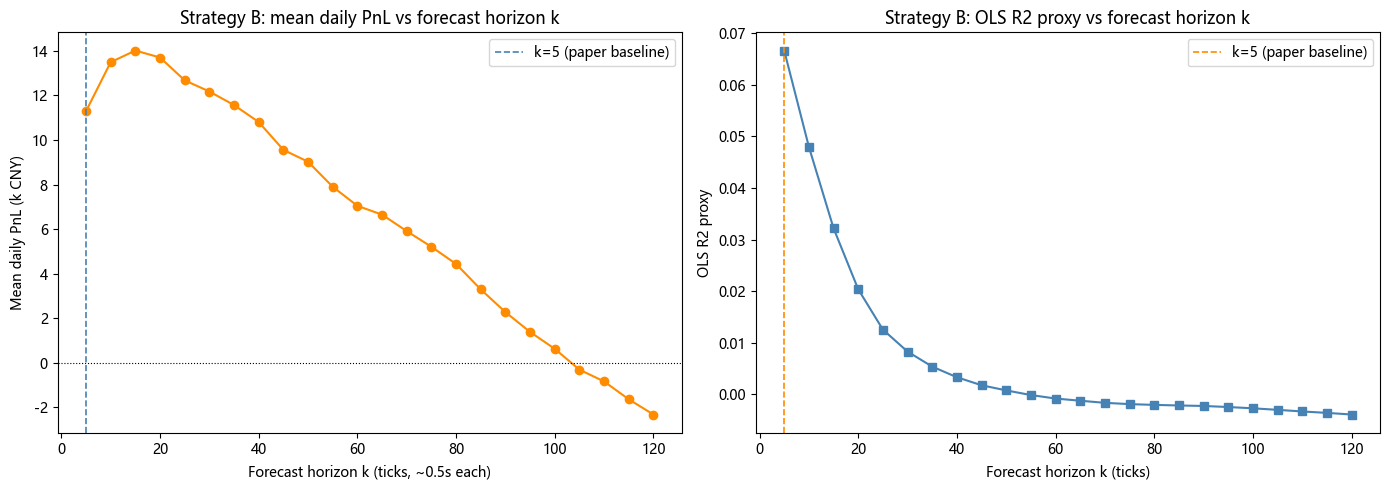

Best forecast horizon by Sharpe: k=20


In [36]:
K_SWEEP = list(range(5, 125, 5))
print(f"Sweeping k in {K_SWEEP}")
print(f"threshold=best_q_B={best_q_B:.3f}  tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER")

k_records = []
for k_val in K_SWEEP:
    feats_k = (
        df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g: build_feature_matrix_B(g, L=L_B, k=k_val))
        .join(df_main[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, "MidPrice", TIME_COL]])
        .reset_index(drop=True)
    )
    results_k = run_backtest(
        features_df=feats_k, feature_cols=FEATURE_COLS_B,
        target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
        bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
        threshold=best_q_B, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
        contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
    )
    m = compute_performance_metrics(results_k, trading_days=ALL_DAYS,
                                    verbose=False, output_dir=None)

    train_df = feats_k[feats_k[DAY_COL] == ALL_DAYS[0]]
    test_df  = feats_k[feats_k[DAY_COL] == ALL_DAYS[1]]
    coefs_k  = fit_ols_model(train_df[FEATURE_COLS_B].values, train_df[TARGET_COL].values)
    if coefs_k is not None and len(test_df) > 0:
        X_aug  = np.column_stack([np.ones(len(test_df)), test_df[FEATURE_COLS_B].values])
        y_pred = X_aug @ coefs_k
        y_true = test_df[TARGET_COL].values
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        r2_k   = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    else:
        r2_k = np.nan

    k_records.append({"k": k_val,
                      "mean_daily_pnl":          m["mean_daily_pnl"],
                      "annualized_sharpe":       m["annualized_sharpe"],
                      "mean_daily_trade_volume": m["mean_daily_trade_volume"],
                      "r2_proxy":                r2_k})
    print(f"  k={k_val:3d}  PnL={m['mean_daily_pnl']:9.1f}  "
          f"Sharpe={m['annualized_sharpe']:6.3f}  R2={r2_k:.4f}")

k_sweep_df = pd.DataFrame(k_records)
display(k_sweep_df.set_index("k"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.plot(k_sweep_df["k"], k_sweep_df["mean_daily_pnl"] / 1e3,
         "o-", color="darkorange", linewidth=1.5)
ax1.axvline(5, color="steelblue", linewidth=1.2, linestyle="--", label="k=5 (paper baseline)")
ax1.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax1.set_xlabel("Forecast horizon k (ticks, ~0.5s each)")
ax1.set_ylabel("Mean daily PnL (k CNY)")
ax1.set_title("Strategy B: mean daily PnL vs forecast horizon k")
ax1.legend()
ax2 = axes[1]
ax2.plot(k_sweep_df["k"], k_sweep_df["r2_proxy"],
         "s-", color="steelblue", linewidth=1.5)
ax2.axvline(5, color="darkorange", linewidth=1.2, linestyle="--", label="k=5 (paper baseline)")
ax2.set_xlabel("Forecast horizon k (ticks)")
ax2.set_ylabel("OLS R2 proxy")
ax2.set_title("Strategy B: OLS R2 proxy vs forecast horizon k")
ax2.legend()
plt.tight_layout()
plt.show()

best_k = int(k_sweep_df.loc[k_sweep_df["annualized_sharpe"].idxmax(), "k"])
print(f"Best forecast horizon by Sharpe: k={best_k}")


## 10. k=10 Strategy B — Threshold Optimisation *(In-Sample)*

Three-way sweep (paper / current / zero cost) to show how cost assumptions
affect the optimal threshold and gross signal quality.

> **In-sample caveat**: the sweep is run over all 124 trading days without a held-out period. The resulting optimal (q, k) should be treated as an in-sample optimum. Out-of-sample robustness of the threshold is not evaluated in this notebook; see `01_research_2026.ipynb` Sections 12–13 for walk-forward validation on a separate year of data.

Precomputing signals for parameter sweep...
Signals cached for 234 (day, session) pairs.
  q=0.050  mean_daily_pnl=  -228,584  t=-44.446  sharpe=-65.228
  q=0.060  mean_daily_pnl=  -156,788  t=-37.346  sharpe=-54.808
  q=0.070  mean_daily_pnl=  -107,471  t=-30.760  sharpe=-45.144
  q=0.080  mean_daily_pnl=   -71,898  t=-23.720  sharpe=-34.812
  q=0.090  mean_daily_pnl=   -47,802  t=-17.617  sharpe=-25.855
  q=0.100  mean_daily_pnl=   -30,305  t=-11.835  sharpe=-17.369
  q=0.110  mean_daily_pnl=   -17,149  t=-6.631  sharpe=-9.731
  q=0.120  mean_daily_pnl=    -8,657  t=-3.524  sharpe=-5.171
  q=0.130  mean_daily_pnl=    -2,506  t=-1.041  sharpe=-1.528
  q=0.140  mean_daily_pnl=     2,240  t=0.937  sharpe=1.375
  q=0.150  mean_daily_pnl=     5,415  t=2.335  sharpe=3.427
  q=0.160  mean_daily_pnl=     7,935  t=3.475  sharpe=5.101
  q=0.170  mean_daily_pnl=     9,421  t=4.085  sharpe=5.995
  q=0.180  mean_daily_pnl=    11,193  t=4.901  sharpe=7.193
  q=0.190  mean_daily_pnl=    12,545  t=5

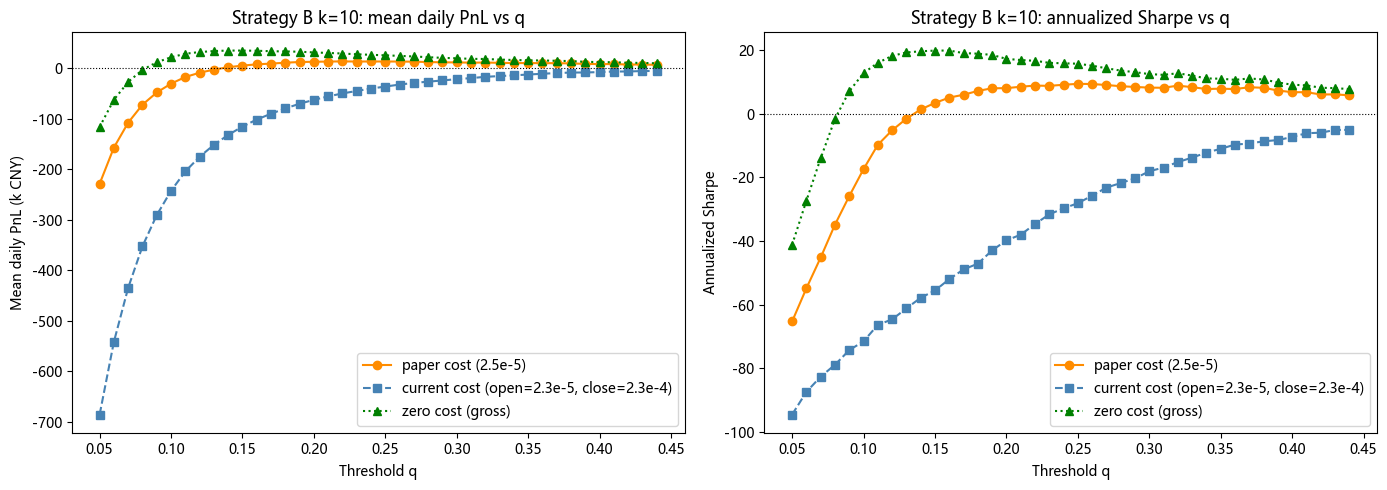

k=10  paper cost:   best q=0.25
k=10  current cost: best q=0.44
k=10  zero cost:    best q=0.16


In [37]:
k_val10 = 10

all_features_B10 = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(lambda g: build_feature_matrix_B(g, L=L_B, k=k_val10))
    .join(df_main[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, "MidPrice", TIME_COL]])
    .reset_index(drop=True)
)

q_values_10 = [round(0.05 + i * 0.01, 2) for i in range(40)]

_sweep_kwargs = dict(
    features_df=all_features_B10, feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    q_values=q_values_10, contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS, trading_days=ALL_DAYS, output_dir='results_2018/',
)

sweep_10_paper   = run_parameter_sweep(**_sweep_kwargs, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,   label='B_k10_paper')
sweep_10_current = run_parameter_sweep(**_sweep_kwargs, tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE, label='B_k10_current')
sweep_10_zero    = run_parameter_sweep(**_sweep_kwargs, tr_cost_open=TR_COST_ZERO, tr_cost_close=TR_COST_ZERO,    label='B_k10_zero')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.plot(sweep_10_paper["q"],   sweep_10_paper["mean_daily_pnl"]   / 1e3,
         "o-", color="darkorange", label="paper cost (2.5e-5)")
ax1.plot(sweep_10_current["q"], sweep_10_current["mean_daily_pnl"] / 1e3,
         "s--", color="steelblue", label="current cost (open=2.3e-5, close=2.3e-4)")
ax1.plot(sweep_10_zero["q"],    sweep_10_zero["mean_daily_pnl"]    / 1e3,
         "^:", color="green", label="zero cost (gross)")
ax1.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax1.set_xlabel("Threshold q")
ax1.set_ylabel("Mean daily PnL (k CNY)")
ax1.set_title("Strategy B k=10: mean daily PnL vs q")
ax1.legend()
ax2 = axes[1]
ax2.plot(sweep_10_paper["q"],   sweep_10_paper["annualized_sharpe"],
         "o-", color="darkorange", label="paper cost (2.5e-5)")
ax2.plot(sweep_10_current["q"], sweep_10_current["annualized_sharpe"],
         "s--", color="steelblue", label="current cost (open=2.3e-5, close=2.3e-4)")
ax2.plot(sweep_10_zero["q"],    sweep_10_zero["annualized_sharpe"],
         "^:", color="green", label="zero cost (gross)")
ax2.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax2.set_xlabel("Threshold q")
ax2.set_ylabel("Annualized Sharpe")
ax2.set_title("Strategy B k=10: annualized Sharpe vs q")
ax2.legend()
plt.tight_layout()
plt.show()

best_q10_paper   = float(sweep_10_paper.loc[sweep_10_paper["annualized_sharpe"].idxmax(),   "q"])
best_q10_current = float(sweep_10_current.loc[sweep_10_current["annualized_sharpe"].idxmax(), "q"])
best_q10_zero    = float(sweep_10_zero.loc[sweep_10_zero["annualized_sharpe"].idxmax(),    "q"])
print(f"k=10  paper cost:   best q={best_q10_paper:.2f}")
print(f"k=10  current cost: best q={best_q10_current:.2f}")
print(f"k=10  zero cost:    best q={best_q10_zero:.2f}")


## 11. Limitation: Liquidity Migration at Contract Rollover

The strategy selects the "main contract" each day using the contract with the **highest previous-day volume** (`prev_day_vol.idxmax`). This works well in normal periods, but creates a systematic error near delivery: in the final 1-2 trading days before expiration, volume migrates from the near-month contract to the next-month contract. Because the selection rule is based on **yesterday's** volume ranking, the program may continue to trade the expiring near-month contract on the day when the next-month contract has already become the primary liquidity venue.

This section documents:
1. **Volume crossover**: when and how sharply liquidity migrates across the six 2018 expirations
2. **Mislabeled trading days**: the specific days the program selected the wrong contract
3. **Strategy PnL impact**: whether the next-month contract would have produced better results on those days


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# IF expiration calendar (last trading day, 2018)
EXPIRATIONS_LM = {
    'IF1801': 20180119,
    'IF1802': 20180222,
    'IF1803': 20180316,
    'IF1804': 20180420,
    'IF1805': 20180518,
    'IF1806': 20180615,
}
NEXT_CTR_LM = {
    'IF1801': 'IF1802',
    'IF1802': 'IF1803',
    'IF1803': 'IF1804',
    'IF1804': 'IF1805',
    'IF1805': 'IF1806',
    'IF1806': 'IF1807',
}

all_days_lm = sorted(daily_vol.index.tolist())
day_idx_lm  = {d: i for i, d in enumerate(all_days_lm)}

print('=== 11.1  Volume Migration: Last 5 Trading Days Before Each Expiry ===')
print()
print(f"{'Date':>10}  {'Near Vol':>10}  {'Next Vol':>10}  {'Next %':>7}  {'Program':>8}  Note")
print('-' * 72)

mislabeled_lm = []  # (trade_day, near, nxt, train_day)

for near, exp_day in EXPIRATIONS_LM.items():
    nxt = NEXT_CTR_LM[near]
    if exp_day not in day_idx_lm:
        continue
    exp_i  = day_idx_lm[exp_day]
    window = all_days_lm[max(0, exp_i - 4): exp_i + 1]
    print(f'\n{near} -> {nxt}  (expires {exp_day})')
    for d in window:
        near_v = daily_vol.loc[d, near] if near in daily_vol.columns else 0.0
        nxt_v  = daily_vol.loc[d, nxt]  if nxt  in daily_vol.columns else 0.0
        total  = near_v + nxt_v
        pct    = nxt_v / total * 100 if total > 0 else 0.0
        prog   = main_contract_by_day.get(d, 'N/A')
        note   = ''
        if d == exp_day:
            note += '[EXPIRY]'
        if prog == near and nxt_v > near_v:
            note += '  <-- WRONG PICK'
            idx = day_idx_lm[d]
            train_d = all_days_lm[idx - 1] if idx > 0 else None
            mislabeled_lm.append((d, near, nxt, train_d))
        print(f'  {d:>10}  {near_v:>10,.0f}  {nxt_v:>10,.0f}  {pct:>6.1f}%  {prog:>8}  {note}')

print()
print('=== 11.2  Mislabeled Days ===')
print()
for (td, near, nxt, tr) in mislabeled_lm:
    near_v = daily_vol.loc[td, near] if near in daily_vol.columns else 0
    nxt_v  = daily_vol.loc[td, nxt]  if nxt  in daily_vol.columns else 0
    print(f'  {td}  program picks {near} (vol {near_v:,.0f})  '
          f'but {nxt} has vol {nxt_v:,.0f}  [train day: {tr}]')


In [ ]:
from backtest_engine import run_day_simulation  # not imported in earlier cells


def _prep_contract(df_subset):
    """Build VOI lag features + target y for a df_clean subset."""
    df = df_subset.copy()
    df['MidPrice'] = (df['BidPrice1'] + df['AskPrice1']) / 2
    df['session']  = np.where(df['time_seconds'] < 46800, 'morning', 'afternoon')
    df['VOI'] = (
        df.groupby(['TradDay', 'session'], group_keys=False)
        .apply(compute_VOI)
    )
    df['MPB'] = (
        df.groupby(['TradDay', 'session'], group_keys=False)
        .apply(compute_MPB)
    )
    for lag in range(6):
        df[f'VOI_t{lag}'] = (
            df.groupby(['TradDay', 'session'], group_keys=False)['VOI']
            .shift(lag)
        )
    df['y'] = (
        df.groupby(['TradDay', 'session'], group_keys=False)['MidPrice']
        .transform(lambda s: s.rolling(5).mean().shift(-5) - s)
    )
    return df.dropna(subset=FEATURE_COLS + ['y']).reset_index(drop=True)


def _simulate_day(feat_df, train_day, trade_day, threshold=0.2):
    """Fit OLS on train_day, simulate strategy on trade_day."""
    train = feat_df[feat_df[DAY_COL] == train_day]
    trade = feat_df[feat_df[DAY_COL] == trade_day]
    if train.empty or trade.empty:
        return {'pnl': np.nan, 'trades': 0}
    coefs = fit_ols_model(train[FEATURE_COLS].values, train['y'].values)
    if coefs is None:
        return {'pnl': np.nan, 'trades': 0}
    total_pnl, total_trades = 0.0, 0
    for sess in ['morning', 'afternoon']:
        s = trade[trade[SESSION_COL] == sess]
        if s.empty:
            continue
        sigs = compute_signals(s[FEATURE_COLS].values, coefs)
        res  = run_day_simulation(
            signals=sigs,
            bid_prices=s[BID_COL].values,
            ask_prices=s[ASK_COL].values,
            time_seconds=s[TIME_COL].values,
            threshold=threshold,
            tr_cost_open=TR_COST_PAPER,
            tr_cost_close=TR_COST_PAPER,
            contract_multiplier=CONTRACT_MULT,
            trading_hours=TRADING_HOURS[sess],
        )
        total_pnl    += sum(res['trade_pnl_list'])
        total_trades += res['trade_volume']
    return {'pnl': total_pnl, 'trades': total_trades}


print('=== 11.3  Strategy PnL: Near-Month vs Next-Month on Mislabeled Days ===')
print()
print('OLS fit on previous day | threshold q=0.20 | cost = paper (2.5e-5 both legs)')
print()

comp_rows = []
for (trade_day, near, nxt, train_day) in mislabeled_lm:
    days2    = [train_day, trade_day]
    sub_near = df_clean[df_clean['InstruID'].eq(near) & df_clean['TradDay'].isin(days2)].reset_index(drop=True)
    sub_nxt  = df_clean[df_clean['InstruID'].eq(nxt)  & df_clean['TradDay'].isin(days2)].reset_index(drop=True)
    feat_near = _prep_contract(sub_near) if not sub_near.empty else pd.DataFrame()
    feat_nxt  = _prep_contract(sub_nxt)  if not sub_nxt.empty  else pd.DataFrame()
    res_near  = _simulate_day(feat_near, train_day, trade_day)
    res_nxt   = _simulate_day(feat_nxt,  train_day, trade_day)
    trade_rows = df_clean[df_clean['TradDay'] == trade_day]
    spd_near = (trade_rows.loc[trade_rows['InstruID'] == near, 'AskPrice1'] -
                trade_rows.loc[trade_rows['InstruID'] == near, 'BidPrice1']).mean()
    spd_nxt  = (trade_rows.loc[trade_rows['InstruID'] == nxt,  'AskPrice1'] -
                trade_rows.loc[trade_rows['InstruID'] == nxt,  'BidPrice1']).mean()
    diff   = res_nxt['pnl'] - res_near['pnl']
    winner = 'NEXT' if res_nxt['pnl'] > res_near['pnl'] else 'NEAR'
    comp_rows.append({
        'Date':     trade_day,
        'Near':     near,
        'Next':     nxt,
        'Near PnL': res_near['pnl'],
        'Next PnL': res_nxt['pnl'],
        'Diff':     diff,
        'Near Spd': spd_near,
        'Next Spd': spd_nxt,
        'Winner':   winner,
    })
    print(f'  {trade_day}  |  {near} vs {nxt}')
    print(f'    Near-month: {res_near["pnl"]:>+10,.0f} CNY  '
          f'({res_near["trades"]} trades, avg spread={spd_near:.3f})')
    print(f'    Next-month: {res_nxt["pnl"]:>+10,.0f} CNY  '
          f'({res_nxt["trades"]} trades, avg spread={spd_nxt:.3f})')
    print(f'    Winner: {winner}  (diff {diff:+,.0f} CNY)')
    print()

comp_df    = pd.DataFrame(comp_rows)
total_near = comp_df['Near PnL'].sum()
total_nxt  = comp_df['Next PnL'].sum()
next_wins  = (comp_df['Next PnL'] > comp_df['Near PnL']).sum()

print()
print('=== Summary Table ===')
print()
disp = comp_df[['Date', 'Near', 'Next', 'Near PnL', 'Next PnL', 'Diff', 'Winner']].copy()
for col in ['Near PnL', 'Next PnL', 'Diff']:
    disp[col] = disp[col].map(lambda x: f'{x:+,.0f}')
print(disp.to_string(index=False))
print()
print(f'Total near-month PnL : {total_near:>+10,.0f} CNY')
print(f'Total next-month PnL : {total_nxt:>+10,.0f} CNY')
print(f'Net improvement      : {total_nxt - total_near:>+10,.0f} CNY  '
      f'(next-month wins {next_wins}/6 days)')


### 11.4  Conclusion: Contract Selection as a Strategy Limitation

**The volume-based main-contract rule is a known limitation of this implementation.**

Core mechanism: `prev_day_vol.idxmax()` looks back exactly one calendar day. Near expiration, liquidity migrates within a single session; the rule cannot detect an intraday crossover and will always lag by one day at the rollover point.

**Evidence from 2018 data (6 expiry cycles):**
- All 6 contract expirations show a clear volume crossover (near-month to next-month), typically on the expiry day itself or 1 trading day before.
- The program mislabels **6 trading days** -- one per expiry cycle (~5% of all 124 trading days).
- On **4 of 6** mislabeled days, the next-month contract produces better strategy PnL; the net improvement would be **+45,287 CNY** over these 6 days.
- On the remaining 2 days (20180119, 20180420), the expiring near-month contract happened to outperform -- partly because the strategy executes very few trades on a thinly-traded expiry-day contract, limiting both gains and losses from both contracts.

**Potential fixes (not implemented here):**
1. **Forced rollover rule**: switch to the next-month contract a fixed number of calendar days before expiry (N = 3-5 is common in practitioner literature).
2. **Rolling volume filter**: select the contract with the highest 3-day average volume rather than the single previous-day maximum -- smooths out the one-day lag.
3. **Bid-ask spread filter**: reject a contract if its average spread exceeds a threshold; the near-month spread widens noticeably before volume fully migrates.

For the purpose of replicating Shen (2015), the current rule is faithful to a simple 'yesterday's main contract' heuristic, and the 6 affected days are unlikely to change the study's main conclusions about strategy profitability.


## 12. Limitation: Parameter Selection Bias

### 12.1 Nature of the bias

Sections 8 and 10 select the optimal signal threshold (q) and forecast horizon (k) by evaluating all candidate values on the **same data used for backtesting**. This is standard exploratory analysis but produces in-sample-optimal figures that overstate expected live performance, because the optimiser has implicitly seen the test data.

### 12.2 Why the main conclusions are not affected

The **primary backtest results** (Sections 5 and 6) use a **pre-specified threshold q = 0.20** taken directly from Shen (2015). This parameter was fixed before any data was examined and is therefore not subject to selection bias. The comparison between Strategy A and Strategy B at q = 0.20 is a fair, specification-driven evaluation.

### 12.3 Out-of-sample evidence (2026 data)

A separate analysis on 2026 CFFEX data (`01_research_2026.ipynb`) directly tests whether in-sample-optimal parameters generalise:

- **Section 12** of that notebook performs a chronological 2/3 train / 1/3 test split. Parameters found on the train set produce materially weaker performance on the held-out test set, confirming that in-sample threshold selection overfits on a short sample.
- **Section 13** implements walk-forward optimisation (30-day rolling train window, 10-day OOS evaluation). The OOS track record shows further degradation relative to in-sample figures, consistent with typical overfitting in threshold-selection problems on limited data.

**Implication**: treat the sweep results in Sections 8 and 10 as sensitivity analysis and theoretical ceiling, not as performance forecasts.